## We will create:

1. Baseline Forecasting Model Using:

* Prophet

* Goal:
*  Create first demand forecast benchmark.

2. Baseline Churn Prediction Model Using:

* Logistic Regression

* Goal:
*  Create first churn benchmark.

3. MLflow Tracking Track:

* experiments
* metrics
* parameters
* model versions

In [2]:
import pandas as pd

In [3]:
daily_sales = pd.read_csv(
    "../Data/processed/daily_sales_features.csv"
)

In [4]:
rfm = pd.read_csv("../Data/processed/rfm_features.csv")

## Prophet is good at:

* seasonality
* trends
* business time-series

In [5]:
forecast_df = daily_sales.groupby('InvoiceDate')['Quantity'].sum().reset_index()

In [6]:
forecast_df.columns = ['ds','y']

In [7]:
forecast_df['ds'] = pd.to_datetime(forecast_df['ds'])

In [8]:
train_size = int(len(forecast_df)*0.8)

In [9]:
train = forecast_df[:train_size]

test = forecast_df[train_size:]

In [12]:
from prophet import Prophet

In [13]:
model = Prophet()

In [14]:
model.fit(train)

23:05:04 - cmdstanpy - INFO - Chain [1] start processing
23:05:17 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
future = model.make_future_dataframe(periods = len(test))

In [16]:
forecast = model.predict(test)

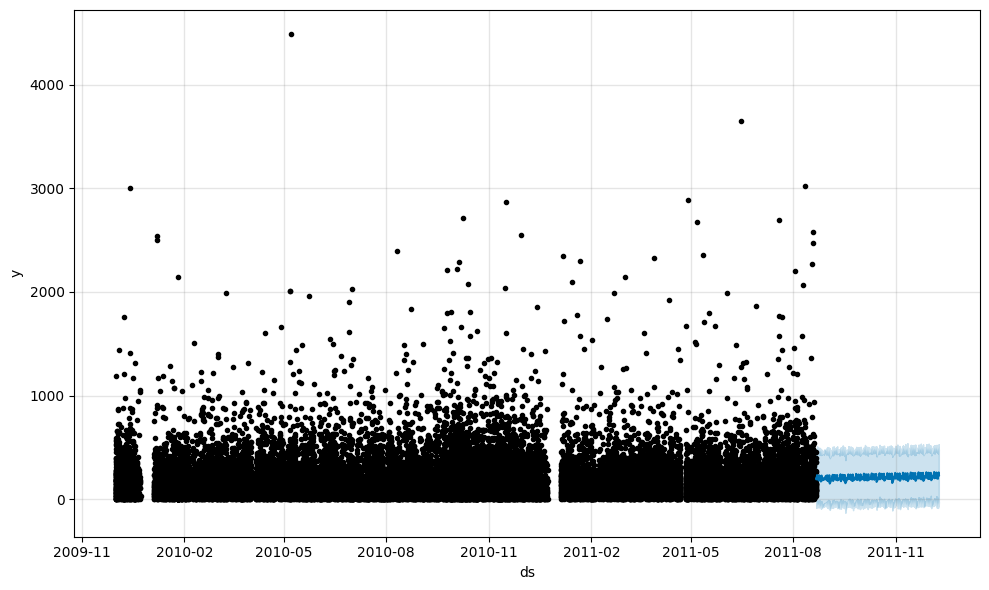

In [17]:
fig = model.plot(forecast)

In [18]:
predictions = forecast[['ds','yhat']].tail(
    len(test)
)

In [19]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    test['y'],
    predictions['yhat']
)

print("MAE:", mae)

MAE: 147.11982890861225


# Churn Prediction Baseline

## Churn means:

* customer stops purchasing

* This directly supports NeuralRetail’s retention engine.

In [20]:
rfm['Churn'] = (
    rfm['Recency'] > 90
).astype(int)

In [21]:
X = rfm[['Recency','Frequency','Monetary']]

y = rfm['Churn']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

clf.fit(X_train, y_train)

LogisticRegression()

In [24]:
y_pred = clf.predict(X_test)

In [25]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

print(
    accuracy_score(y_test, y_pred)
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       589
           1       1.00      1.00      1.00       587

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



 ## MLflow Setup

In [26]:
import mlflow

In [27]:
with mlflow.start_run():

    mlflow.log_param(
        "model",
        "Prophet"
    )

    mlflow.log_metric(
        "MAE",
        mae
    )

2026/05/26 23:05:44 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/26 23:05:44 INFO mlflow.store.db.utils: Updating database tables


In [28]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

with mlflow.start_run():

    mlflow.log_param(
        "model",
        "LogisticRegression"
    )

    mlflow.log_metric(
        "accuracy",
        accuracy
    )

In [ ]:
# By end of Day 4 you will have:

1. Forecasting Baseline Using Prophet

2. Churn Prediction Baseline

Using Logistic Regression

3. ML Experiment Tracking

Using MLflow

4. Benchmark Metrics

Examples:

MAE
Accuracy
Classification Report
Important Understanding

Today’s models are:

BASELINES

They are intentionally simple.

Later you’ll replace them with:

LSTM
XGBoost
LightGBM
ensembles